Vedo的适用范围：非常适合数据量不大、且分布明显的时候使用，用于科学论文的图表绘制。

在论文撰写中，图表的清晰和吸引人的展示方式是至关重要的。箱线图（Whisker Plot）是一种展示数据分布的经典工具，它不仅可以清楚地显示数据的中心趋势、散布和异常值，还能以视觉上吸引人的方式呈现这些信息。

使用 Python 的 vedo 库，我们可以创建不仅信息丰富但也极具视觉冲击力的箱线图。这种图表的美观程度足以让你的科学论文（SCI）中的数据展示部分变得更加引人注目。

首先需要安装vedo库，该库提供了一些高级绘图函数，感兴趣的同学可以自行探索。

https://vedo.embl.es/#gallery

In [1]:
pip install vedo -i https://pypi.douban.com/simple/

Looking in indexes: https://pypi.douban.com/simple/
Note: you may need to restart the kernel to use updated packages.


DEPRECATION: pyodbc 4.0.0-unsupported has a non-standard version number. pip 24.0 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pyodbc or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063


总体上，vedo库也是图层语言，通过不同图层叠加绘图。

In [2]:
from vedo import np, settings, Axes, Brace, Line, Ribbon, show
from vedo.pyplot import whisker

settings.default_font = "Theemim"
#设置了默认字体为 "Theemim"，以确保图表的文本具有良好的可读性和美观性。

接着，代码构建了一个置信区间（灰色区域）和均值线来表示趋势或标准：

In [3]:
# build some theoretical expectation to be shown as a grey band
x = np.linspace(-1, 9, 100)
y = x/5 + 0.2*np.sin(x)
ye= y**2/5 + 0.1 # error on y
line = Line(np.c_[x, y])
band = Ribbon(np.c_[x, y-ye], np.c_[x, y+ye]).c('black',0.1)
#这里 x 和 y 用于生成一条线，ye 代表 y 的误差。Line 和 Ribbon 用于生成这个理论值的可视化表示。

打印Line和Ribbon图层，我们可以看到构建结果：


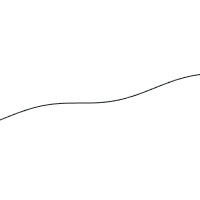

In [4]:
line


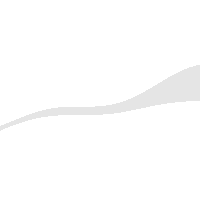

In [5]:
band

注意这里的数据是随机生成的。

代码的核心部分是创建五个不同的箱线图：

In [6]:
# create 5 whisker bars with some random data
ws = []
for i in range(5):
    xval = i*2 # position along x axis
    data = xval/5 + 0.2*np.sin(xval) + np.random.randn(25)
    w = whisker(data, bc=i, s=0.5).x(xval)
    ws.append(w)
    # print(i, 'whisker:\n', w.info)

这段代码对五个不同的数据集生成了箱线图。每个数据集根据 xval（沿x轴的位置）和一些随机噪声生成。

随后，代码添加了一些额外的注释和标签，以增强图表的可读性和信息量：

In [7]:
# build braces to inndicate stats significance and dosage
bra1 = Brace([0, 3],[2, 3], comment='*~*', s=0.7, style='[')
bra2 = Brace([4,-1],[8,-1], comment='ET (mmd^-1 ) > mean', s=0.4)

这些 Brace 对象用于在图表中指示统计学上的显著性或其他注释。

最后，代码设置了自定义的坐标轴，并显示了整个图表：

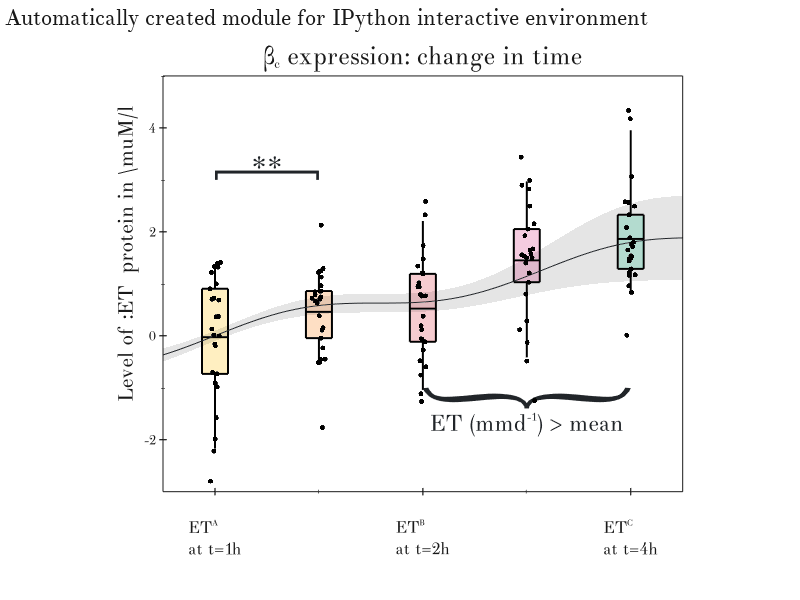

In [8]:
# build custom axes
axes = Axes(xrange=[-1,9],
            yrange=[-3,5],
            htitle=':beta_c  expression: change in time',
            xtitle=' ',
            ytitle='Level of :ET  protein in \muM/l',
            x_values_and_labels=[(0,'ET^A\n at t=1h'),
                                 (4,'ET^B\n at t=2h'),
                                 (8,'ET^C\n at t=4h'),
                                ],
            xlabel_size=0.02,
            xygrid=False,
           )

show(ws, bra1, bra2, line, band, __doc__, axes, zoom=1.3)

#这里 Axes 定义了坐标轴的外观和范围，show 函数则用于渲染和展示整个图表。

参考文献：

https://github.com/marcomusy/vedo

https://vedo.embl.es/#gallery